Question Number 1: Data Exploration of tandem data

About Dataset: Trip Duration (seconds) , Start Time and Date , End Time and Date ,
Start Station ID , Start Station Name , Start Station Latitude , Start Station Longitude , End
Station ID , End Station Name, End Station Latitude , End Station Longitude , Bike ID ,
User Type (Subscriber or Customer – “Subscriber” = Member or “Customer” = Casual) ,
Member Year of Birth, Member Gender

a. Read the entire dataset using pandas dataframe and build the file by appending
each file in an optimized manner

b. What was the time duration for the average trip taken? (Use plotting techniques and
write your observations for the same.)

c. Is there any correlation between the months and the trip duration? Use scatter plot
and comment your observations from the plot

d. Do seasons affect the duration of a trip ? Comment your observations.

e. Using multivariate exploration, explain whether there is any relation between short
trips and the users.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
files = ['201803-fordgobike-tripdata.csv', '201807-fordgobike-tripdata.csv', '201811-fordgobike-tripdata.csv', '201812-fordgobike-tripdata.csv']
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
df.to_csv('fordgobike-tripdata.csv', index=True)

Average trip duration: 13.91 minutes


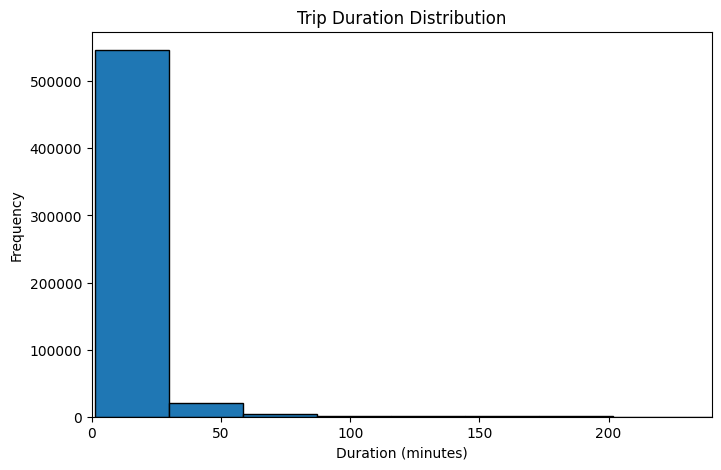

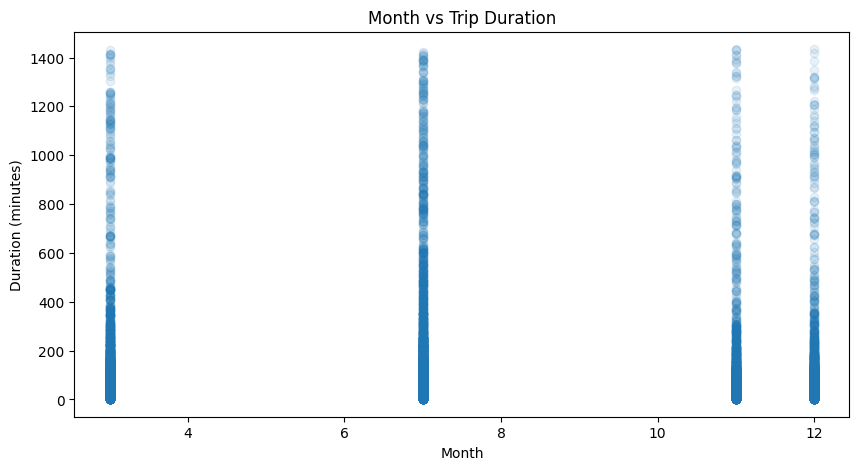


Monthly average duration:
Month
3     14.510832
7     15.128510
11    12.632567
12    12.844589
Name: duration_sec, dtype: float64


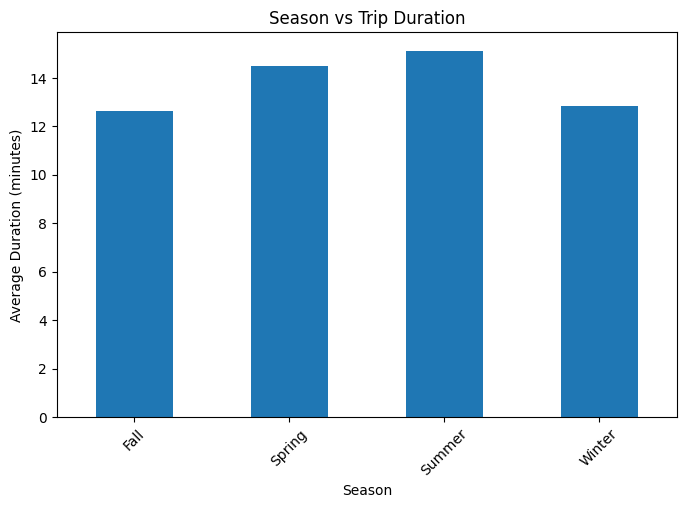

<Figure size 800x500 with 0 Axes>

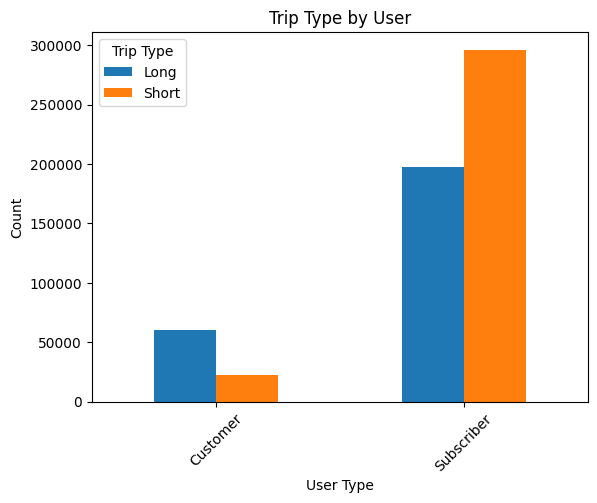


Trip type distribution by user:
Trip Type     Long   Short
user_type                 
Customer     60608   21997
Subscriber  197250  296247


In [14]:
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])
df['Month'] = df['start_time'].dt.month
df['Season'] = df['Month'].apply(lambda x:'Winter' if x in [12,1,2] else 'Spring' if x in [3,4,5] else 'Summer' if x in [6,7,8] else 'Fall')
avg_duration = df['duration_sec'].mean()/60
print(f"Average trip duration: {avg_duration:.2f} minutes")

plt.figure(figsize=(8, 5))
plt.hist(df['duration_sec'] / 60, bins=50, edgecolor='black')
plt.xlim(0,240)
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.title('Trip Duration Distribution')
plt.show()
monthly_avg = df.groupby('Month')['duration_sec'].mean() / 60

plt.figure(figsize=(10, 5))
plt.scatter(df['Month'], df['duration_sec'] / 60, alpha=0.1)
plt.xlabel('Month')
plt.ylabel('Duration (minutes)')
plt.title('Month vs Trip Duration')
plt.show()
print("\nMonthly average duration:")
print(monthly_avg)
season_avg = df.groupby('Season')['duration_sec'].mean() / 60
plt.figure(figsize=(8, 5))
season_avg.plot(kind='bar')
plt.xlabel('Season')
plt.ylabel('Average Duration (minutes)')
plt.title('Season vs Trip Duration')
plt.xticks(rotation=45)
plt.show()

df['Trip Type'] = df['duration_sec'].apply(lambda x: 'Short' if x < 600 else 'Long')
user_trip = pd.crosstab(df['user_type'], df['Trip Type'])
plt.figure(figsize=(8, 5))
user_trip.plot(kind='bar')
plt.xlabel('User Type')
plt.ylabel('Count')
plt.title('Trip Type by User')
plt.xticks(rotation=45)
plt.legend(title='Trip Type')
plt.show()
print("\nTrip type distribution by user:")
print(user_trip)


Question Number 2:

a. Create a Matrix between 0 and 1, with each value difference of 0.01.

b. Create an array of 20 linearly spaced points between 0 and 1.

c. Create a 5*5 matrix using range 1 to 26, and return sum of the matrix, standard
deviation and sum of all the columns of the matrix.

In [17]:
import numpy as np
matrix_01 = np.arange(0, 1, 0.04).reshape(5,5)
print("Matrix between 0 and 1:")
print(matrix_01)
array_b =np.linspace(0,1,20)
print("\n20 linearly spaced points:")
print(array_b)

matrix_c = np.arange(1, 26).reshape(5, 5)
print("\n5x5 Matrix:")
print(matrix_c)
print(f"\nSum of matrix: {matrix_c.sum()}")
print(f"Standard deviation: {matrix_c.std()}")
print(f"Sum of columns:\n{matrix_c.sum(axis=0)}")

Matrix between 0 and 1:
[[0.   0.04 0.08 0.12 0.16]
 [0.2  0.24 0.28 0.32 0.36]
 [0.4  0.44 0.48 0.52 0.56]
 [0.6  0.64 0.68 0.72 0.76]
 [0.8  0.84 0.88 0.92 0.96]]

20 linearly spaced points:
[0.         0.05263158 0.10526316 0.15789474 0.21052632 0.26315789
 0.31578947 0.36842105 0.42105263 0.47368421 0.52631579 0.57894737
 0.63157895 0.68421053 0.73684211 0.78947368 0.84210526 0.89473684
 0.94736842 1.        ]

5x5 Matrix:
[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]]

Sum of matrix: 325
Standard deviation: 7.211102550927978
Sum of columns:
[55 60 65 70 75]


Question Number 3:

import numpy as np

x = np.arange(0,100)

y = x*2

z = x**2

a. Create a figure object and axis of the figure canvas at axis1 = [0,0,1,1]. Provide
necessary labels and title to the plot.

b. Create another plot at axis1 = [0,0,1,1] and axis2 = [0.2,0.5,0.2,0.2]

c. Create a plot by adding two axis object at [0,0,1,1] & [0.2,0.5,0.4,0.4]

d. Use x, y, z array to create the plots

i. Between x and z arrays

ii. Between x & y arrays by setting the x-limit in range 20-22 and y-limit range in
30-50

[  0   2   4   6   8  10  12  14  16  18  20  22  24  26  28  30  32  34
  36  38  40  42  44  46  48  50  52  54  56  58  60  62  64  66  68  70
  72  74  76  78  80  82  84  86  88  90  92  94  96  98 100 102 104 106
 108 110 112 114 116 118 120 122 124 126 128 130 132 134 136 138 140 142
 144 146 148 150 152 154 156 158 160 162 164 166 168 170 172 174 176 178
 180 182 184 186 188 190 192 194 196 198]
[   0    1    4    9   16   25   36   49   64   81  100  121  144  169
  196  225  256  289  324  361  400  441  484  529  576  625  676  729
  784  841  900  961 1024 1089 1156 1225 1296 1369 1444 1521 1600 1681
 1764 1849 1936 2025 2116 2209 2304 2401 2500 2601 2704 2809 2916 3025
 3136 3249 3364 3481 3600 3721 3844 3969 4096 4225 4356 4489 4624 4761
 4900 5041 5184 5329 5476 5625 5776 5929 6084 6241 6400 6561 6724 6889
 7056 7225 7396 7569 7744 7921 8100 8281 8464 8649 8836 9025 9216 9409
 9604 9801]


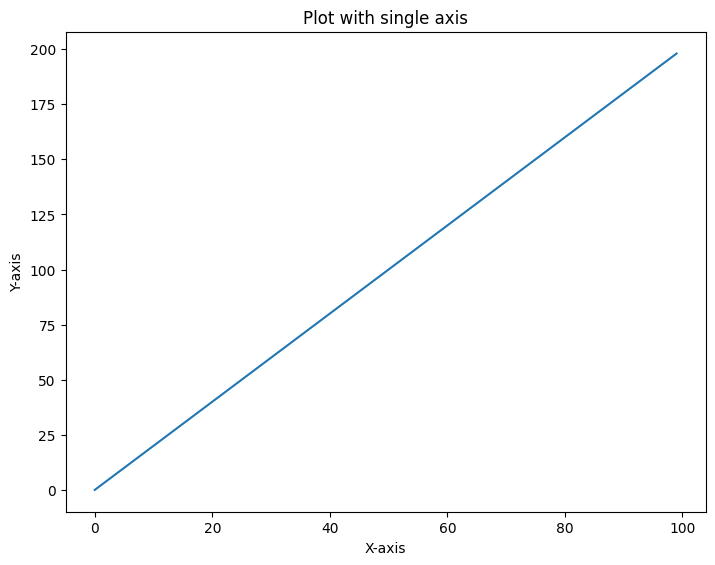

<Figure size 640x480 with 0 Axes>

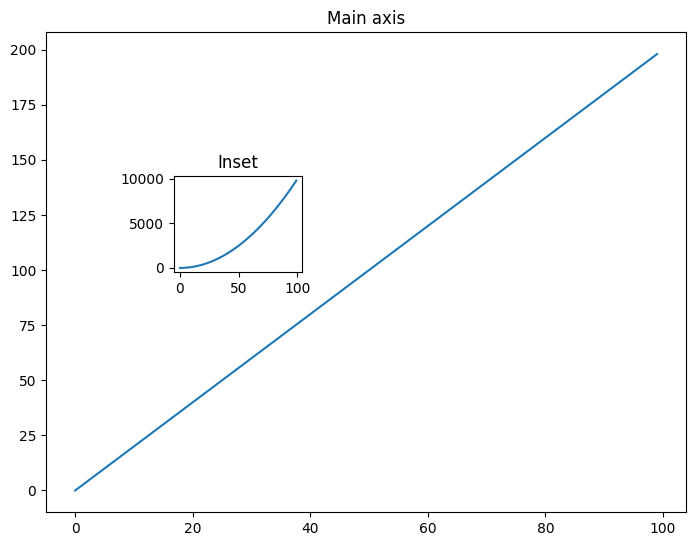

<Figure size 640x480 with 0 Axes>

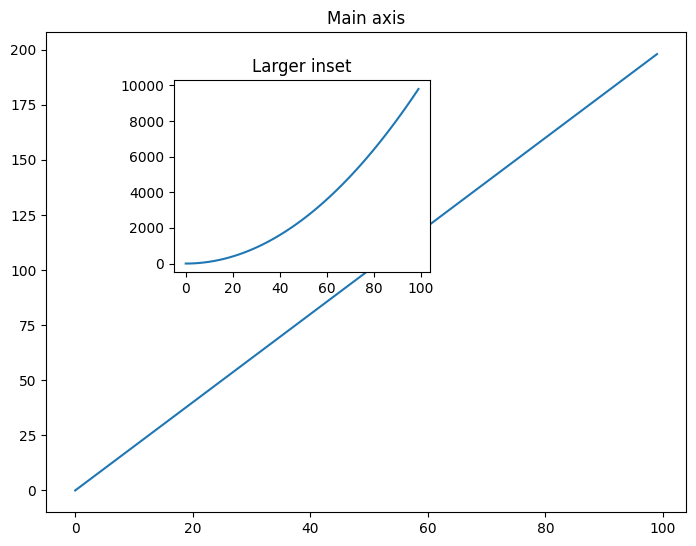

In [26]:
import numpy as np
import matplotlib.pyplot as plt
x = np.arange(0,100)
y = x*2
z = x**2
print(y)
print(z)

ax1=plt.figure()
ax1=ax1.add_axes([0,0,1,1])
ax1.plot(x, y)
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_title('Plot with single axis')
plt.show()
ax1=plt.figure()
fig=plt.figure()
ax1=fig.add_axes([0,0,1,1])
ax2=fig.add_axes([0.2,0.5,0.2,0.2])
ax1.plot(x, y)
ax2.plot(x, z)
ax1.set_title('Main axis')
ax2.set_title('Inset')
plt.show()
ax1=plt.figure()
fig=plt.figure()
ax1=fig.add_axes([0,0,1,1])
ax2=fig.add_axes([0.2,0.5,0.4,0.4])
ax1.plot(x,y)
ax2.plot(x,z)
ax1.set_title('Main axis')
ax2.set_title('Larger inset')
plt.show()

Question Number 4: The purchase analysis of walmart.

a. What is the average Purchase Price?

b. What were the highest and lowest purchase prices?

c. How many people have English 'en' as their Language of choice on the website?

d. What is the email of the person with the following Credit Card Number:
4926535242672853

e. Someone made a purchase that came from Lot: "90 WT" , what was the Purchase
Price for this transaction?

f. How many people have American Express as their Credit Card Provider and made
a purchase above $95 ?

g. How many people have a credit card that expires in 2025?

h. What are the top 5 most popular email providers/hosts (e.g. gmail.com, yahoo.com,
etc...) ?

i. What are the 5 most common Job Titles?

j. How many people made the purchase during morning and evening time?

In [30]:
df=pd.read_csv('walmart_purchase_data.csv')

avg_price = df['Purchase Price'].mean()
print(f"Average Purchase Price: ${avg_price:.2f}")

highest=df['Purchase Price'].max()
lowest=df['Purchase Price'].min()
print(f"Highest: ${highest:.2f}")
print(f"Lowest: ${lowest:.2f}")
english_count=len(df[df['Language'] == 'en'])
print(f"English language users: {english_count}")
email=df[df['Credit Card'] == 4926535242672853]['Email'].values[0]
print(f"Email: {email}")
price=df[df['Lot']=='90 WT']['Purchase Price'].values[0]
print(f"Purchase Price for Lot 90 WT: ${price:.2f}")
amex_count=len(df[(df['CC Provider']=='American Express') & (df['Purchase Price'] > 95)])
print(f"American Express purchases > $95: {amex_count}")
expires_2025=len(df[df['CC Exp Date'].str.contains('2025')])
print(f"Cards expiring in 2025: {expires_2025}")
df['Email Provider']=df['Email'].str.split('@').str[1]
top_providers=df['Email Provider'].value_counts().head(5)
print("\nTop 5 Email Providers:")
print(top_providers)
top_jobs=df['Job'].value_counts().head(5)
print("\nTop 5 Job Titles:")
print(top_jobs)

morning=len(df[(df['AM or PM'] == 'AM')])
evening=len(df[(df['AM or PM'] == 'PM')])
print(f"\nMorning purchases (5 AM - 12 PM): {morning}")
print(f"Evening purchases (5 PM - 9 PM): {evening}")

Average Purchase Price: $50.35
Highest: $99.99
Lowest: $0.00
English language users: 1098
Email: bondellen@williams-garza.com
Purchase Price for Lot 90 WT: $75.10
American Express purchases > $95: 39
Cards expiring in 2025: 0

Top 5 Email Providers:
Email Provider
hotmail.com     1638
yahoo.com       1616
gmail.com       1605
smith.com         42
williams.com      37
Name: count, dtype: int64

Top 5 Job Titles:
Job
Interior and spatial designer        31
Lawyer                               30
Social researcher                    28
Designer, jewellery                  27
Research officer, political party    27
Name: count, dtype: int64

Morning purchases (5 AM - 12 PM): 4932
Evening purchases (5 PM - 9 PM): 5068
